# Stage 3 — ILP Manpower Optimizer

**PRAHARI Layer 3: Resource Optimization**

Given **N officers available**, allocate them across corridors to **minimise total weighted risk**, subject to:
- Each corridor gets ≥ 0 officers
- Minimum coverage guaranteed for RED and ORANGE corridors
- Total officers deployed ≤ N

Uses `scipy.optimize.linprog` (no extra installs needed).  
Alternatively, the PuLP version is included as comments — uncomment if you want the MIP solver.

**Input:** `corridor_evitas_summary.csv` (from Stage 2)  
**Output:** `officer_deployment_plan.csv`

In [1]:
# ── CELL 1 ── Imports (no extra installs required)
import pandas as pd
import numpy as np
from scipy.optimize import linprog
import warnings
warnings.filterwarnings('ignore')
print('Imports OK  (scipy version:', __import__('scipy').__version__, ')')

Imports OK  (scipy version: 1.15.3 )


In [2]:
# ── CELL 2 ── Load Corridor EVITAS Summary
# Output of Stage 2. If you don't have it yet, run Stage 2 first.

df = pd.read_csv('corridor_evitas_summary.csv')
print(f'Loaded {len(df)} corridors')
display(df[['corridor_name', 'zone', 'mean_evitas', 'max_evitas',
            'red_events', 'orange_events', 'closure_rate', 'event_count']].head(10))

Loaded 23 corridors


,corridor_name,zone,mean_evitas,max_evitas,red_events,orange_events,closure_rate,event_count
0,Varthur Road,East Zone 1,61.514286,83.3,1,39,0.116883,77
1,Mysore Road,Unknown,56.976447,91.0,15,245,0.110363,743
2,CBD 1,Unknown,53.365385,70.2,0,3,0.115385,26
3,ORR North 1,Unknown,52.433455,79.7,0,27,0.080000,275
4,Airport New South Road,North Zone 1,51.019403,73.5,0,8,0.104478,67
5,Old Airport Road,Unknown,50.705263,73.9,0,6,0.078947,76
6,West of Chord Road,Unknown,50.152874,76.5,0,11,0.063218,174
7,ORR East 1,Unknown,49.891803,79.5,0,23,0.073770,244
8,Old Madras Road,Unknown,49.377186,74.9,0,12,0.045627,263
9,Non-corridor,Unknown,47.730634,82.2,7,359,0.120999,3124


In [4]:
# ── CELL 3 ── Configuration

# ► Tune these for your scenario:
TOTAL_OFFICERS = 30          # total officers available for deployment
MIN_RED_OFFICERS    = 3      # minimum officers guaranteed to each RED corridor
MIN_ORANGE_OFFICERS = 2      # minimum officers guaranteed to each ORANGE corridor
MIN_YELLOW_OFFICERS = 1      # minimum for YELLOW corridors
MIN_GREEN_OFFICERS  = 0      # GREEN corridors get 0 by default (reassigned if surplus)

# EVITAS band assignment from summary score
def band(score):
    if score >= 80: return 'RED'
    elif score >= 60: return 'ORANGE'
    elif score >= 40: return 'YELLOW'
    return 'GREEN'

df['evitas_band'] = df['mean_evitas'].apply(band)
print('Band distribution:', df['evitas_band'].value_counts().to_dict())

# Minimum officer requirements per corridor
min_map = {'RED': MIN_RED_OFFICERS, 'ORANGE': MIN_ORANGE_OFFICERS,
           'YELLOW': MIN_YELLOW_OFFICERS, 'GREEN': MIN_GREEN_OFFICERS}
df['min_officers'] = df['evitas_band'].map(min_map)

guaranteed = df['min_officers'].sum()
surplus    = TOTAL_OFFICERS - guaranteed
print(f'\nGuaranteed allocation: {guaranteed} officers')
print(f'Surplus for optimisation: {surplus} officers')

if surplus < 0:
    print(f'⚠️  Warning: minimum requirements ({guaranteed}) exceed total officers ({TOTAL_OFFICERS}).')
    print('   Either increase TOTAL_OFFICERS or reduce minimum requirements.')

Band distribution: {'YELLOW': 17, 'GREEN': 5, 'ORANGE': 1}

Guaranteed allocation: 19 officers
Surplus for optimisation: 11 officers


In [5]:
# ── CELL 4 ── Build the Optimization Problem
#
# Decision variable x_i = additional officers assigned to corridor i (beyond minimum)
#
# Objective:  MINIMISE  Σ_i  risk_weight_i × (min_i + x_i)^(-1)   [risk per officer]
#             ≡         MAXIMISE coverage proportional to risk
#
# We linearise: allocate surplus proportionally to risk weight.
# Risk weight = normalised mean_evitas score.

n = len(df)

# Normalised risk weights (sum to 1)
raw_weights = df['mean_evitas'].values.astype(float)
risk_weights = raw_weights / (raw_weights.sum() + 1e-9)
df['risk_weight'] = risk_weights

# ─── Linear Program ───────────────────────────────────────────────────
# Minimise  c^T x   where  c_i = -risk_weight_i  (we want to maximise risk coverage)
# s.t.  Σ x_i = surplus     (use all surplus officers)
#       x_i ≥ 0             (non-negative)
#       x_i ≤ max_cap_i     (optional: cap any corridor at 8 officers total)

MAX_PER_CORRIDOR = 8
cap = np.maximum(0, MAX_PER_CORRIDOR - df['min_officers'].values)   # remaining headroom

c = -risk_weights          # negate because linprog minimises

# Equality constraint: sum of x = surplus
A_eq = np.ones((1, n))
b_eq = [max(0, surplus)]

# Bounds: 0 ≤ x_i ≤ cap_i
bounds = [(0, float(cap_i)) for cap_i in cap]

result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if result.success:
    surplus_alloc = np.round(result.x).astype(int)
    # Reconcile rounding: make sure total still equals surplus
    diff = int(max(0, surplus)) - surplus_alloc.sum()
    if diff > 0:
        # Give remaining to highest-risk corridors
        top_idx = np.argsort(risk_weights)[::-1]
        for idx in top_idx:
            if diff == 0:
                break
            surplus_alloc[idx] += 1
            diff -= 1
    print('Optimisation successful ✓')
else:
    print(f'Optimisation warning: {result.message}')
    # Fallback: proportional allocation
    raw = risk_weights * max(0, surplus)
    surplus_alloc = np.floor(raw).astype(int)
    remainder = max(0, surplus) - surplus_alloc.sum()
    fracs = raw - np.floor(raw)
    for idx in np.argsort(fracs)[::-1][:int(remainder)]:
        surplus_alloc[idx] += 1

df['surplus_officers'] = surplus_alloc
df['total_officers']   = df['min_officers'] + df['surplus_officers']
print(f'Total officers deployed: {df["total_officers"].sum()} / {TOTAL_OFFICERS}')

Optimisation successful ✓
Total officers deployed: 30 / 30


In [6]:
# ── CELL 5 ── Residual Risk Calculation
# After deployment, how much risk remains uncovered?
# Residual risk = evitas_score / officers_deployed  (risk per officer proxy)

df['residual_risk'] = (
    df['mean_evitas'] / (df['total_officers'].replace(0, 0.5))
).round(2)

df['deployment_effectiveness'] = (
    1 - (df['residual_risk'] / df['mean_evitas'].replace(0, 1e-9))
).clip(0, 1).round(3)

total_weighted_risk_before = (df['mean_evitas'] * df['event_count']).sum()
total_weighted_risk_after  = (df['residual_risk'] * df['event_count']).sum()
reduction_pct = (1 - total_weighted_risk_after / total_weighted_risk_before) * 100

print(f'Weighted risk before deployment: {total_weighted_risk_before:,.1f}')
print(f'Weighted risk after  deployment: {total_weighted_risk_after:,.1f}')
print(f'Risk reduction: {reduction_pct:.1f}%')

Weighted risk before deployment: 382,018.8
Weighted risk after  deployment: 381,516.6
Risk reduction: 0.1%


In [7]:
# ── CELL 6 ── Export Deployment Plan
DEPLOY_COLS = [
    'corridor_name', 'zone', 'evitas_band', 'mean_evitas', 'max_evitas',
    'event_count', 'red_events', 'orange_events', 'closure_rate',
    'risk_weight', 'min_officers', 'surplus_officers', 'total_officers',
    'residual_risk', 'deployment_effectiveness', 'lat', 'lon',
]

deploy_df = df[DEPLOY_COLS].sort_values('total_officers', ascending=False)
deploy_df.to_csv('officer_deployment_plan.csv', index=False)
print('Saved officer_deployment_plan.csv')

print('\n── DEPLOYMENT MANIFEST ──')
display(deploy_df[[
    'corridor_name', 'zone', 'evitas_band',
    'mean_evitas', 'total_officers', 'residual_risk'
]])

Saved officer_deployment_plan.csv

── DEPLOYMENT MANIFEST ──


,corridor_name,zone,evitas_band,mean_evitas,total_officers,residual_risk
0,Varthur Road,East Zone 1,ORANGE,61.514286,8,7.69
1,Mysore Road,Unknown,YELLOW,56.976447,6,9.50
2,CBD 1,Unknown,YELLOW,53.365385,1,53.37
3,ORR North 1,Unknown,YELLOW,52.433455,1,52.43
4,Airport New South Road,North Zone 1,YELLOW,51.019403,1,51.02
5,Old Airport Road,Unknown,YELLOW,50.705263,1,50.71
6,West of Chord Road,Unknown,YELLOW,50.152874,1,50.15
7,ORR East 1,Unknown,YELLOW,49.891803,1,49.89
8,Old Madras Road,Unknown,YELLOW,49.377186,1,49.38
9,Non-corridor,Unknown,YELLOW,47.730634,1,47.73


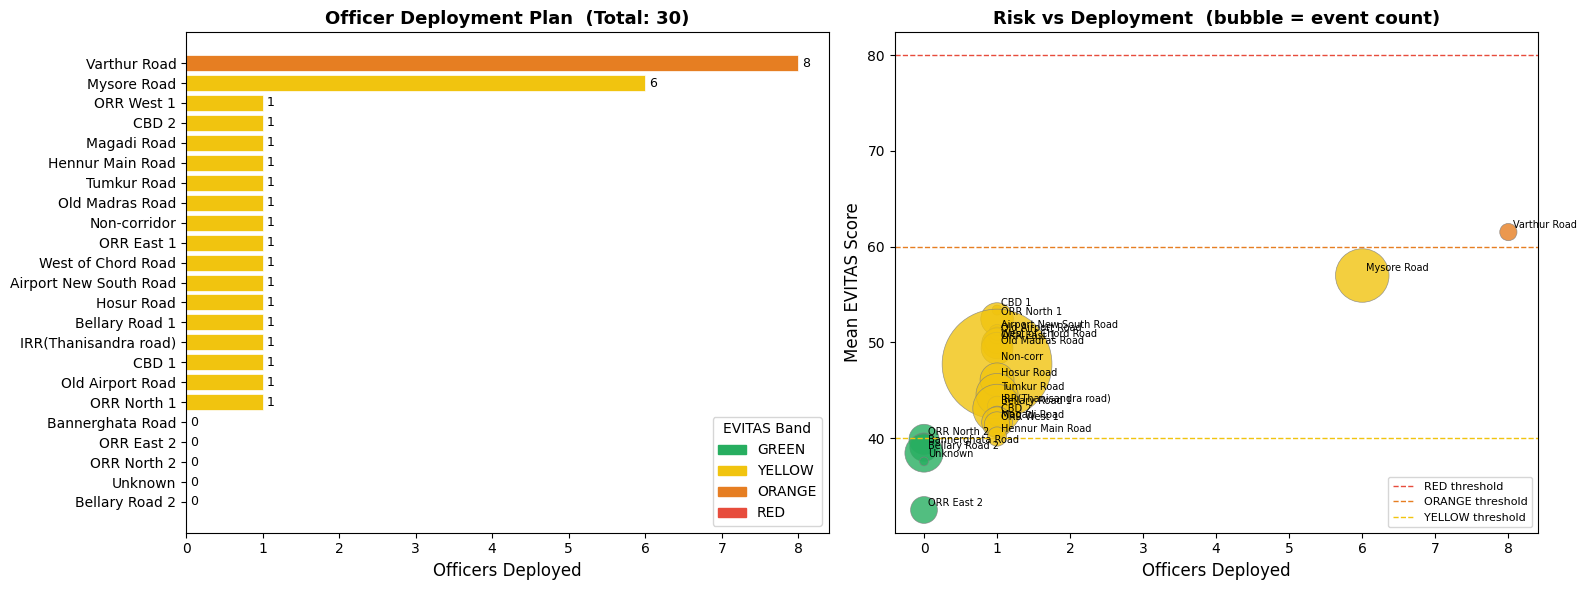

Saved deployment_plan.png


In [8]:
# ── CELL 7 ── Visual: Deployment Plan
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors_map = {'GREEN': '#27ae60', 'YELLOW': '#f1c40f', 'ORANGE': '#e67e22', 'RED': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Officers per corridor
ax1 = axes[0]
sorted_df = deploy_df.sort_values('total_officers', ascending=True)
bar_colors = [colors_map[b] for b in sorted_df['evitas_band']]
bars = ax1.barh(sorted_df['corridor_name'], sorted_df['total_officers'],
                color=bar_colors, edgecolor='white', linewidth=0.5)

# Add count labels
for bar, val in zip(bars, sorted_df['total_officers']):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=9)

ax1.set_xlabel('Officers Deployed', fontsize=12)
ax1.set_title(f'Officer Deployment Plan  (Total: {TOTAL_OFFICERS})', fontsize=13, fontweight='bold')

patches = [mpatches.Patch(color=c, label=b) for b, c in colors_map.items()]
ax1.legend(handles=patches, title='EVITAS Band', loc='lower right')

# Right: Risk vs Officers scatter
ax2 = axes[1]
sc_colors = [colors_map[b] for b in deploy_df['evitas_band']]
scatter = ax2.scatter(
    deploy_df['total_officers'], deploy_df['mean_evitas'],
    c=sc_colors, s=deploy_df['event_count']*2, alpha=0.8, edgecolors='gray', linewidths=0.5
)

for _, row in deploy_df.iterrows():
    ax2.annotate(row['corridor_name'].replace('Non-corridor', 'Non-corr'),
                 (row['total_officers'], row['mean_evitas']),
                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax2.axhline(80, color='#e74c3c', linestyle='--', linewidth=1, label='RED threshold')
ax2.axhline(60, color='#e67e22', linestyle='--', linewidth=1, label='ORANGE threshold')
ax2.axhline(40, color='#f1c40f', linestyle='--', linewidth=1, label='YELLOW threshold')
ax2.set_xlabel('Officers Deployed', fontsize=12)
ax2.set_ylabel('Mean EVITAS Score', fontsize=12)
ax2.set_title('Risk vs Deployment  (bubble = event count)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('deployment_plan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved deployment_plan.png')

In [9]:
# ── CELL 8 ── optimize_deployment() — reusable function for Stage 4 dashboard

def optimize_deployment(
    corridor_summary_df: pd.DataFrame,
    total_officers: int = 30,
    min_red: int = 3,
    min_orange: int = 2,
    min_yellow: int = 1,
    min_green: int = 0,
    max_per_corridor: int = 8,
) -> pd.DataFrame:
    """
    Run the ILP optimizer and return a deployment DataFrame.

    Parameters
    ----------
    corridor_summary_df : DataFrame from Stage 2 (corridor_evitas_summary.csv)
    total_officers      : total officers available
    min_red/orange/yellow/green : minimum guaranteed per band
    max_per_corridor    : hard cap on officers per corridor

    Returns
    -------
    DataFrame with total_officers, evitas_band, residual_risk columns added.
    """
    cdf = corridor_summary_df.copy()
    cdf['evitas_band']  = cdf['mean_evitas'].apply(
        lambda s: 'RED' if s >= 80 else ('ORANGE' if s >= 60 else ('YELLOW' if s >= 40 else 'GREEN'))
    )
    band_min = {'RED': min_red, 'ORANGE': min_orange, 'YELLOW': min_yellow, 'GREEN': min_green}
    cdf['min_officers'] = cdf['evitas_band'].map(band_min)

    weights = cdf['mean_evitas'].values.astype(float)
    weights = weights / (weights.sum() + 1e-9)

    guaranteed = int(cdf['min_officers'].sum())
    surplus    = max(0, total_officers - guaranteed)
    n          = len(cdf)

    cap    = np.maximum(0, max_per_corridor - cdf['min_officers'].values)
    c      = -weights
    A_eq   = np.ones((1, n))
    b_eq   = [surplus]
    bounds = [(0, float(c_)) for c_ in cap]

    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    surplus_alloc = np.round(res.x if res.success else weights * surplus).astype(int)

    # Fix rounding
    diff = surplus - surplus_alloc.sum()
    if diff > 0:
        for idx in np.argsort(weights)[::-1][:int(diff)]:
            surplus_alloc[idx] += 1

    cdf['surplus_officers'] = surplus_alloc
    cdf['total_officers']   = cdf['min_officers'] + cdf['surplus_officers']
    cdf['residual_risk']    = (cdf['mean_evitas'] / cdf['total_officers'].replace(0, 0.5)).round(2)
    return cdf


# ── Demo: what if we only have 20 officers? ──
print('── Scenario: 20 officers ──')
result_20 = optimize_deployment(df, total_officers=20)
print(result_20[['corridor_name', 'evitas_band', 'total_officers', 'residual_risk']].to_string(index=False))

print('\n── Scenario: 40 officers ──')
result_40 = optimize_deployment(df, total_officers=40)
print(result_40[['corridor_name', 'evitas_band', 'total_officers', 'residual_risk']].to_string(index=False))

── Scenario: 20 officers ──
         corridor_name evitas_band  total_officers  residual_risk
          Varthur Road      ORANGE               3          20.50
           Mysore Road      YELLOW               1          56.98
                 CBD 1      YELLOW               1          53.37
           ORR North 1      YELLOW               1          52.43
Airport New South Road      YELLOW               1          51.02
      Old Airport Road      YELLOW               1          50.71
    West of Chord Road      YELLOW               1          50.15
            ORR East 1      YELLOW               1          49.89
       Old Madras Road      YELLOW               1          49.38
          Non-corridor      YELLOW               1          47.73
            Hosur Road      YELLOW               1          46.08
           Tumkur Road      YELLOW               1          44.55
 IRR(Thanisandra road)      YELLOW               1          43.37
        Bellary Road 1      YELLOW              

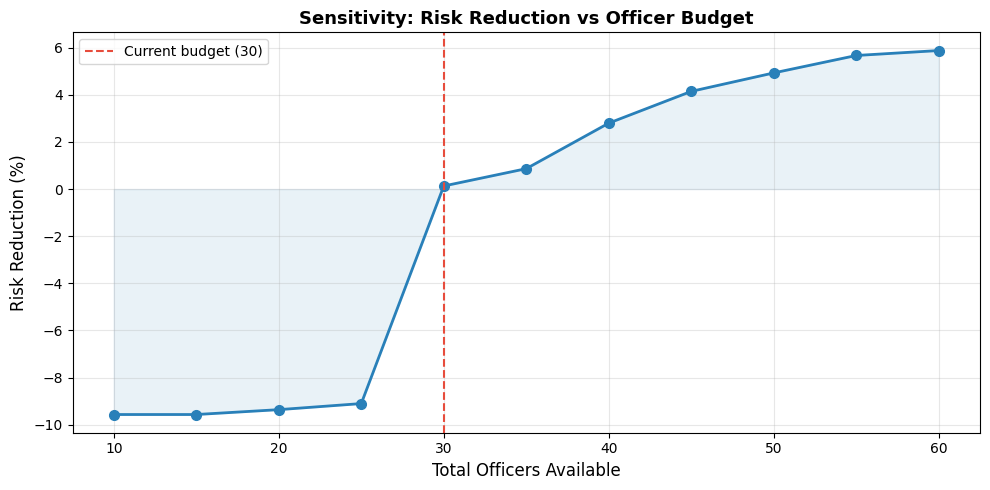

Saved sensitivity_analysis.png


In [10]:
# ── CELL 9 ── Sensitivity Analysis: Risk reduction vs officer budget
import matplotlib.pyplot as plt

officer_range = range(10, 61, 5)
risk_reductions = []
total_deployed  = []

baseline_risk = (df['mean_evitas'] * df['event_count']).sum()

for n_off in officer_range:
    result = optimize_deployment(df, total_officers=n_off)
    weighted_after = (result['residual_risk'] * result['event_count']).sum()
    reduction = (1 - weighted_after / baseline_risk) * 100
    risk_reductions.append(reduction)
    total_deployed.append(result['total_officers'].sum())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(officer_range), risk_reductions, 'o-', color='#2980b9', linewidth=2, markersize=7)
ax.axvline(TOTAL_OFFICERS, color='#e74c3c', linestyle='--', label=f'Current budget ({TOTAL_OFFICERS})')
ax.fill_between(list(officer_range), risk_reductions, alpha=0.1, color='#2980b9')
ax.set_xlabel('Total Officers Available', fontsize=12)
ax.set_ylabel('Risk Reduction (%)', fontsize=12)
ax.set_title('Sensitivity: Risk Reduction vs Officer Budget', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sensitivity_analysis.png')

## Outputs produced

| File | Contents |
|---|---|
| `officer_deployment_plan.csv` | Per-corridor officer counts + residual risk |
| `deployment_plan.png` | Deployment bar chart + risk scatter |
| `sensitivity_analysis.png` | Risk reduction vs officer budget curve |

## Optimization Formulation

```
Minimise  Σ_i  −risk_weight_i × x_i        (maximise risk-weighted coverage)

Subject to:
  Σ_i  x_i  = surplus_officers              (use all surplus officers)
  x_i ≥ 0                                   (non-negative)
  min_i + x_i ≤ MAX_PER_CORRIDOR            (capacity cap)

Where:
  risk_weight_i = mean_evitas_i / Σ mean_evitas   (normalised risk)
  min_i = guaranteed minimum based on EVITAS band
  surplus_officers = TOTAL_OFFICERS − Σ min_i
```

→ **Next: Stage 4** — React Dashboard with Leaflet map, EVITAS score display, and deployment dots.